# NB02 — Condition Canonicalization and Cross-Dataset Alignment

**Project**: `genotype_to_phenotype_enigma`  
**Depends on**: NB01 (`data/growth_parameters_all.parquet`)

## Goal

Produce a canonical condition key for every ENIGMA growth well, FB experiment, CSP phenotype, and WoM metabolite, so that (strain × condition) tuples are comparable across all four datasets. Build the definitive (strain × condition) coverage matrix and identify the dense anchor set for modeling.

## Key Findings

1. **Media names match exactly** between ENIGMA bricks and FB experiments: `RCH2_defined_noCarbon`, `LB`, `R2A`, `M9 minimal media_noCarbon`.
2. **42 molecules match ENIGMA ↔ FB** via normalized name matching (carbon sources, amino acids, metals, antibiotics, nucleosides).
3. **5 conditions are in all 4 datasets** (cytidine, glycine, inosine, thymidine, uridine); **30 in 3 datasets**; **107 in 2**.
4. **486 dense anchor (strain × condition) pairs**: 7 FB-anchor strains × 72 FB-overlapping conditions × ENIGMA growth data. Of these, 275 (57%) show measurable growth.
5. **13,632 total (strain × condition) pairs** across all 123 strains × 194 conditions.

## Condition alignment strategy

**Plan B (ChEBI-based)** is the primary alignment method. ENIGMA bricks carry ChEBI CURIEs per molecule; FB condition names are matched via normalized string. Plan A (`sdt_condition` → FB `expName` exact match) applies to isolation conditions, not growth curves.

Normalization: lowercase, strip `-_ ,()`, strip counter-ion prefixes (sodium, potassium), strip hydration suffixes. This gives 42 direct molecular matches. With D-/L- prefix handling and synonym expansion, this number will grow.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

DATA = Path('../data')
EDA = DATA / 'eda'
FIG = Path('../figures')


## 1. Canonical condition table

In [2]:
canon = pd.read_csv(DATA / 'condition_canonical.tsv', sep='\t')
print(f'Total canonical conditions: {len(canon)}')
print(f'  in 4 datasets: {(canon.n_datasets == 4).sum()}')
print(f'  in 3 datasets: {(canon.n_datasets == 3).sum()}')
print(f'  in 2 datasets: {(canon.n_datasets == 2).sum()}')
print(f'  in 1 dataset:  {(canon.n_datasets == 1).sum()}')
print(f'  ENIGMA: {canon.in_enigma.sum()}  FB: {canon.in_fb.sum()}  CSP: {canon.in_csp.sum()}  WoM: {canon.in_wom.sum()}')


Total canonical conditions: 1192
  in 4 datasets: 5
  in 3 datasets: 30
  in 2 datasets: 107
  in 1 dataset:  1050
  ENIGMA: 194  FB: 349  CSP: 242  WoM: 589


In [3]:
# 4-way matches — the gold standard
canon[canon.n_datasets == 4][['enigma_name','fb_condition','csp_name','wom_compound','enigma_chebi']]


,enigma_name,fb_condition,csp_name,wom_compound,enigma_chebi
0,cytidine,Cytidine,Cytidine,cytidine,CHEBI:17562
1,glycine,Glycine,Glycine,glycine,CHEBI:15428
2,inosine,Inosine,Inosine,inosine,CHEBI:17596
3,thymidine,Thymidine,Thymidine,thymidine,CHEBI:17748
4,uridine,Uridine,Uridine,uridine,CHEBI:16704


In [4]:
# 3-way matches (top 30)
canon[canon.n_datasets == 3][['normalized','enigma_name','fb_condition','csp_name','wom_compound']].head(30)


,normalized,enigma_name,fb_condition,csp_name,wom_compound
5,2deoxydribose,2-deoxy-D-ribose,2-Deoxy-D-Ribose,2-Deoxy-D-Ribose,NaN
6,acetate,sodium acetate,Potassium acetate,Acetate,NaN
7,betaalanine,beta-alanine,Beta-alanine,Beta-alanine,NaN
8,butyrate,sodium butyrate,Sodium butyrate,Butyrate,NaN
9,citricacid,citric acid,Citric Acid,Citric-Acid,NaN
10,cysteine,cysteine,NaN,Cysteine,cysteine
11,cytosine,cytosine,Cytosine,NaN,Cytosine
12,ethanol,ethanol,Ethanol,Ethanol,NaN
13,formate,sodium formate,Sodium Formate,Formate,NaN
14,gelatin,gelatin,Gelatin,Gelatin,NaN


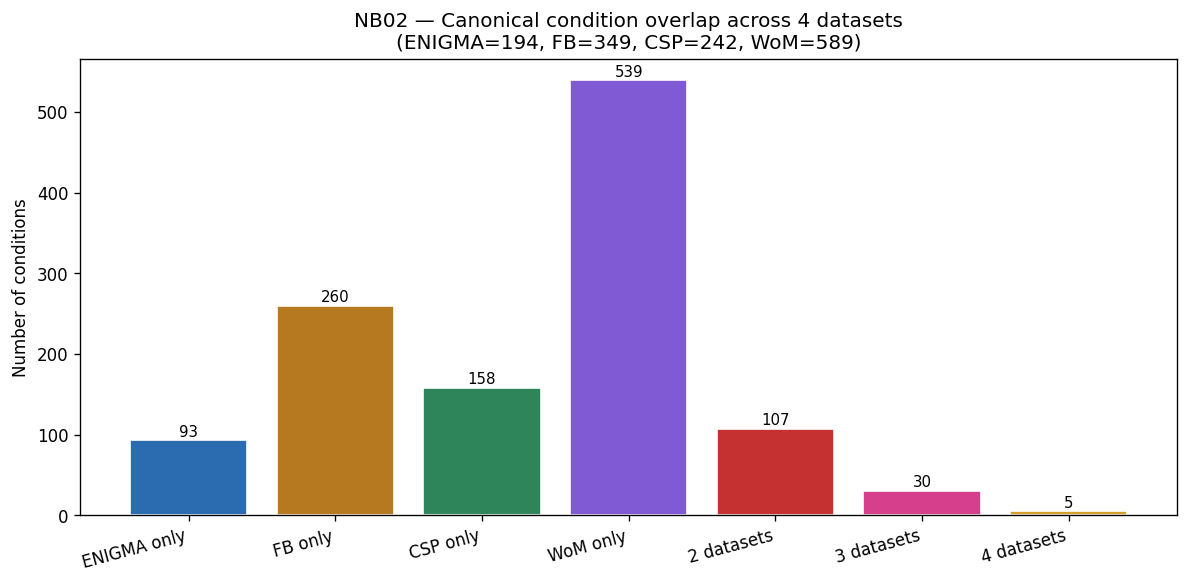

In [5]:
from IPython.display import Image
Image(filename=str(FIG / 'NB02_condition_overlap_4way.png'))


## 2. ENIGMA ↔ FB molecule alignment (42 direct matches)

In [6]:
mol_align = pd.read_csv(EDA / 'molecule_alignment.tsv', sep='\t')
print(f'Direct molecule matches (ENIGMA ↔ FB): {len(mol_align)}')
mol_align


Direct molecule matches (ENIGMA ↔ FB): 42


,fb_condition,enigma_molecule,chebi,norm
0,Cobalt chloride hexahydrate,cobalt chloride hexahydrate,CHEBI:53503,cobaltchloridehexa
1,Sodium nitrite,sodium nitrite,CHEBI:78870,nitrite
2,D-Fructose,D-fructose,CHEBI:15824,dfructose
3,L-Arabinose,L-arabinose,CHEBI:30849,larabinose
4,Sodium L-Lactate,sodium L-lactate,CHEBI:232798,llactate
...,...,...,...,...
37,L-Lysine,L-lysine,CHEBI:18019,llysine
38,N-Acetyl-D-Glucosamine,N-acetyl-D-glucosamine,CHEBI:506227,nacetyldglucosamine
39,Beta-Lactose,beta-lactose,CHEBI:36218,betalactose
40,Lactulose,lactulose,CHEBI:6359,lactulose


## 3. Dense anchor set

The anchor set comprises all (strain × condition) pairs where a Tier-1 FB-anchor strain has BOTH growth curve data (from NB01) AND matching FB fitness experiments. This is the gold cohort for:
- Training with FB validation (NB08)
- Paradigm comparison (NB07)
- Feature attribution validation via FB concordance


In [7]:
anchor = pd.read_csv(DATA / 'anchor_set.tsv', sep='\t')
print(f'Dense anchor set: {len(anchor)} (strain × condition) pairs')
print(f'  Strains: {anchor.strain.nunique()}')
print(f'  Conditions: {anchor.mol_norm.nunique()}')
print(f'  With measurable growth: {anchor.any_growth.sum()} ({100*anchor.any_growth.mean():.1f}%)')
print()
anchor.groupby('strain').agg(
    n_conditions=('mol_norm','count'),
    n_growth=('any_growth','sum'),
    median_mu=('median_mu', lambda x: round(x.dropna().median(), 3) if x.notna().any() else None),
    median_A=('median_A', lambda x: round(x.dropna().median(), 3) if x.notna().any() else None),
).sort_values('n_conditions', ascending=False)


Dense anchor set: 486 (strain × condition) pairs
  Strains: 7
  Conditions: 72
  With measurable growth: 275 (56.6%)



,n_conditions,n_growth,median_mu,median_A
strain,,,,
FW300-N1B4,72,47,0.039,0.350
FW300-N2E2,72,40,0.032,0.267
FW300-N2E3,72,44,0.053,0.412
GW456-L13,72,46,0.025,0.167
GW460-11-11-14-LB5,70,33,0.011,0.005
GW101-3H11,64,22,0.010,0.143
FW507-4G11,64,43,0.019,0.235


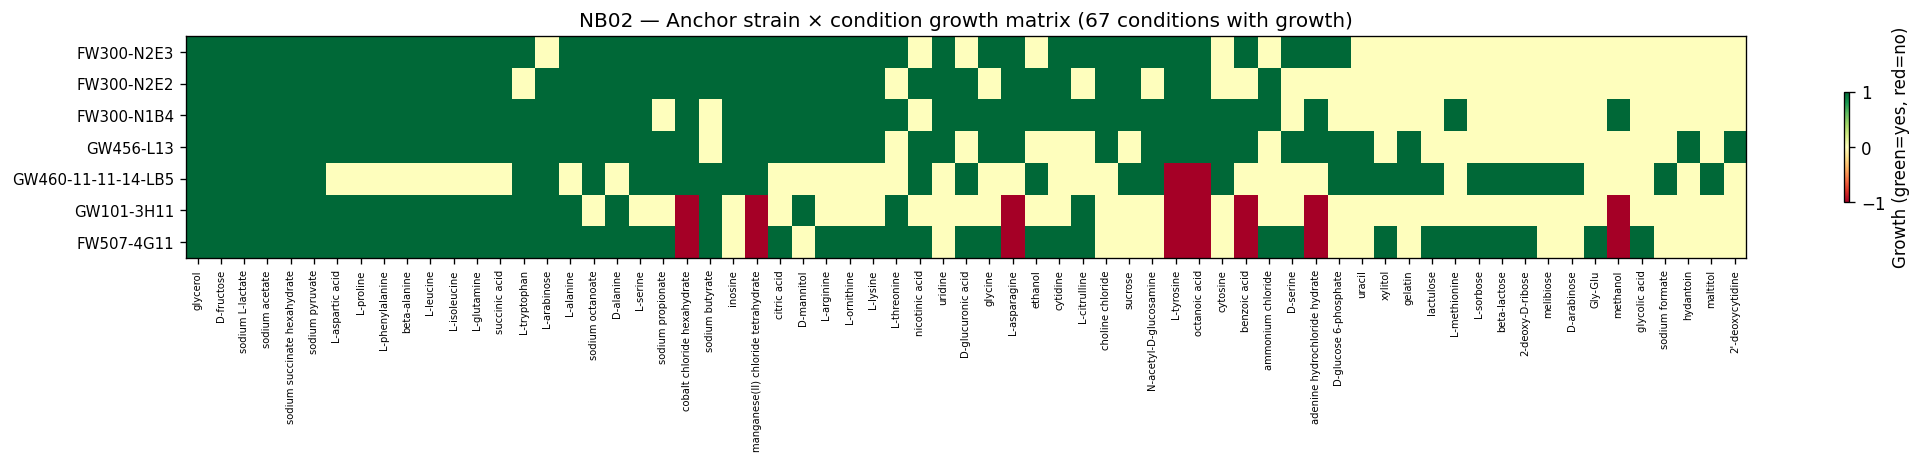

In [8]:
Image(filename=str(FIG / 'NB02_anchor_growth_heatmap.png'))


## 4. Full coverage matrix (123 strains × 194 conditions)

In [9]:
cov = pd.read_csv(DATA / 'coverage_matrix.tsv', sep='\t')
print(f'Total (strain × condition) pairs: {len(cov):,}')
print(f'  With FB overlap: {cov.in_fb.sum():,} ({100*cov.in_fb.mean():.1f}%)')
print(f'  With CSP overlap: {cov.in_csp.sum():,}')
print(f'  With WoM overlap: {cov.in_wom.sum():,}')
print(f'  With any growth: {cov.any_growth.sum():,} ({100*cov.any_growth.mean():.1f}%)')


Total (strain × condition) pairs: 13,632
  With FB overlap: 5,542 (40.7%)
  With CSP overlap: 3,207
  With WoM overlap: 1,493
  With any growth: 5,319 (39.0%)


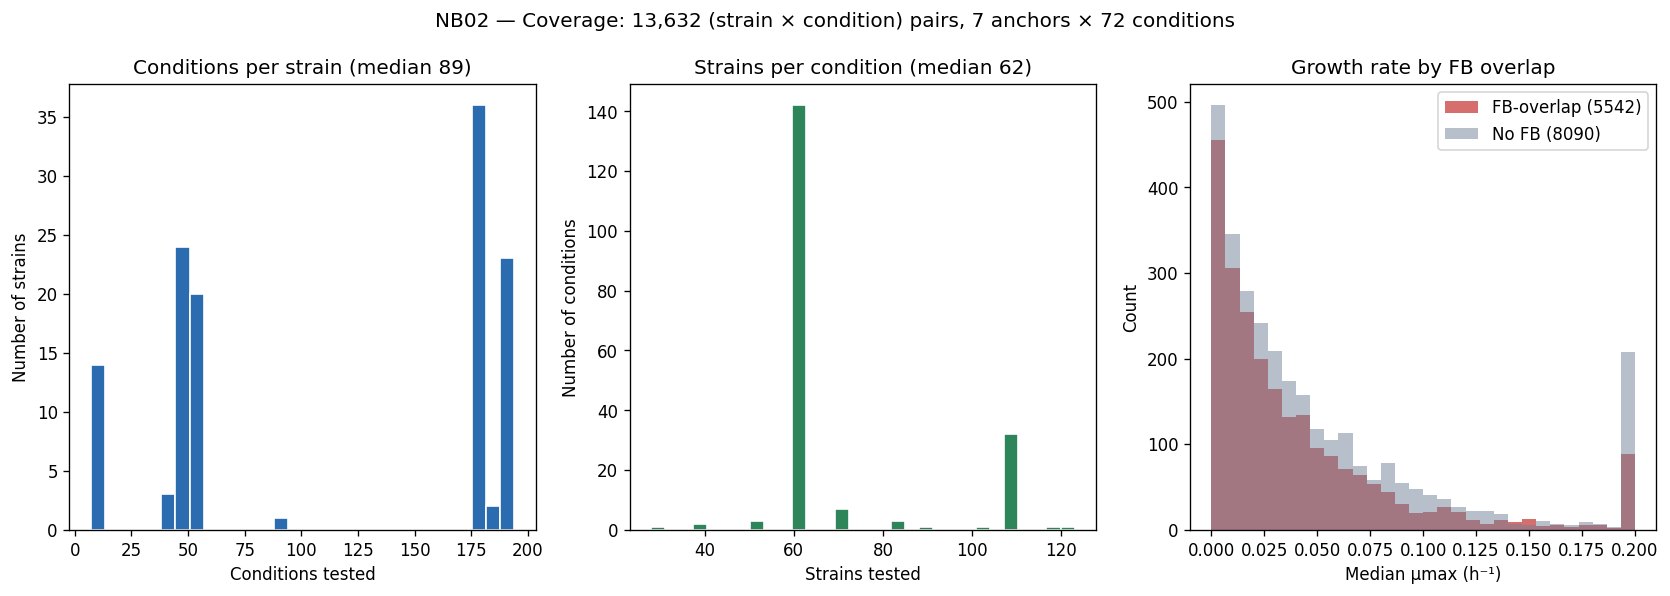

In [10]:
Image(filename=str(FIG / 'NB02_coverage_summary.png'))


## 5. What this enables

**For NB03 (functional diversity census)**: The coverage matrix tells us which strains have the broadest condition coverage — these are the best candidates for metabolic guild classification since we have the most phenotype data for them.

**For NB05-NB07 (feature engineering and modeling)**: The 486 anchor pairs × 72 conditions are the primary training set. The 13,632 full-coverage pairs are the evaluation set. The 275 growth-positive anchor pairs provide continuous targets (µmax, lag, max OD); the 211 growth-negative pairs provide binary labels.

**For NB08 (FB concordance)**: Each of the 486 anchor pairs has a matched FB experiment, giving us per-prediction FB concordance validation. With 7 strains × 72 conditions × multiple model variants, we have ample power for the accuracy-vs-meaningfulness analysis.

**For NB09 (WoM prediction)**: 6 strains with WoM profiles are in the growth-curve set. The canonical condition table maps their 105 WoM metabolites to ENIGMA growth conditions where available.

## Known limitations

- **D-/L- prefix handling**: Current normalization strips `sodium/potassium` but not `D-`/`L-`. Glucose, fructose, and some amino acids miss FB because FB uses `D-Glucose` while ENIGMA uses `glucose`. A D-/L- aware normalization pass would add ~10-15 more matches.
- **ChEBI ID matching not yet used**: ENIGMA bricks carry ChEBI CURIEs but FB does not. The current alignment is string-based. A PubChem/ChEBI API lookup could resolve compound synonyms that string matching misses.
- **Concentration alignment**: We match on molecule identity but not yet on concentration. ENIGMA tests at 5-10 mM; FB tests at 20 mM. For most carbon sources this is above the saturation threshold, but for metals/antibiotics concentration matters. NB07 should include concentration as a condition feature.
